## Some Questions
1) How will this run? This is kinda assuming their is an instance per user


In [1]:
from BayesOpt import * 

## Define Search Space Parameters

We'll optimize three discrete parameters that control cooperation and penalties in the system.

## Initialize the Bayesian Optimizer

Create an optimizer instance with our defined parameters.

In [2]:
opt = TSNEBayesOptimizer(embedding_csv="tsnt.csv", n_init=3, verbose=True)
prolificId = 'Pilot03_16_03'
file = f"submissions/{prolificId}/bayesopt_state_thinpath.json"
opt.load(file)

[OPT - INIT] loaded 51 policies from embedding space
[OPT - INIT] x_range=[-5.030, 6.545], y_range=[-2.128, 6.140] -> normalized to [-1, 1]
[OPT - INIT] kernel=default (Matern 2.5), acqf=qNoisyExpectedImprovement, acqf_options={}
[OPT - LOAD] loaded state from submissions/Pilot03_16_03/bayesopt_state_thinpath.json (13 evaluated policies, n_init=5, n_bo=5, n_knn=3, n_best=1)


In [3]:
opt._optimizer.client.summarize()

,trial_index,arm_name,trial_status,generation_node,performance,emb_x,emb_y
0,0,0_0,ABANDONED,CenterOfSearchSpace,NaN,0.000000,0.000000
1,1,1_0,COMPLETED,NaN,-301.0,0.110532,-0.005115
2,2,2_0,ABANDONED,Sobol,NaN,0.008120,0.285774
3,3,3_0,COMPLETED,NaN,393.0,-0.020118,0.317807
4,4,4_0,ABANDONED,Sobol,NaN,-0.782215,-0.003380
5,5,5_0,COMPLETED,NaN,135.0,-0.729790,0.145916
6,6,6_0,ABANDONED,Sobol,NaN,-0.193173,0.759961
7,7,7_0,COMPLETED,NaN,-80.0,-0.375485,0.676041
8,8,8_0,ABANDONED,Sobol,NaN,0.981826,-0.544827
9,9,9_0,COMPLETED,NaN,-382.0,0.907068,-0.167840


In [4]:
opt.get_best()

[OPT - BEST] policy=a0sp_0_a1sp_0_helping_True_gamma0.8_0.8, coords=(0.352, 0.411), prediction={'performance': (1366.0, nan)}


('a0sp_0_a1sp_0_helping_True_gamma0.8_0.8',
 {'emb_x': 0.35214967440658773, 'emb_y': 0.41145544591766936},
 {'performance': (1366.0, nan)},
 23,
 '22_0')

In [5]:
cards = opt.compute_analyses()
cards

[OPT - BEST] SELECTED trial 23: best_policy='a0sp_0_a1sp_0_helping_True_gamma0.8_0.8', coords=(0.352, 0.411), value=1366.0000
[OPT - BEST] Fitted visualization surrogate model for plots


[OPT - BEST] policy=a0sp_0_a1sp_1_helping_False_gamma0.95_0.8, coords=(0.693, 0.352), prediction={'performance': (np.float64(652.6427412834717), np.float64(16910.376997251482))}


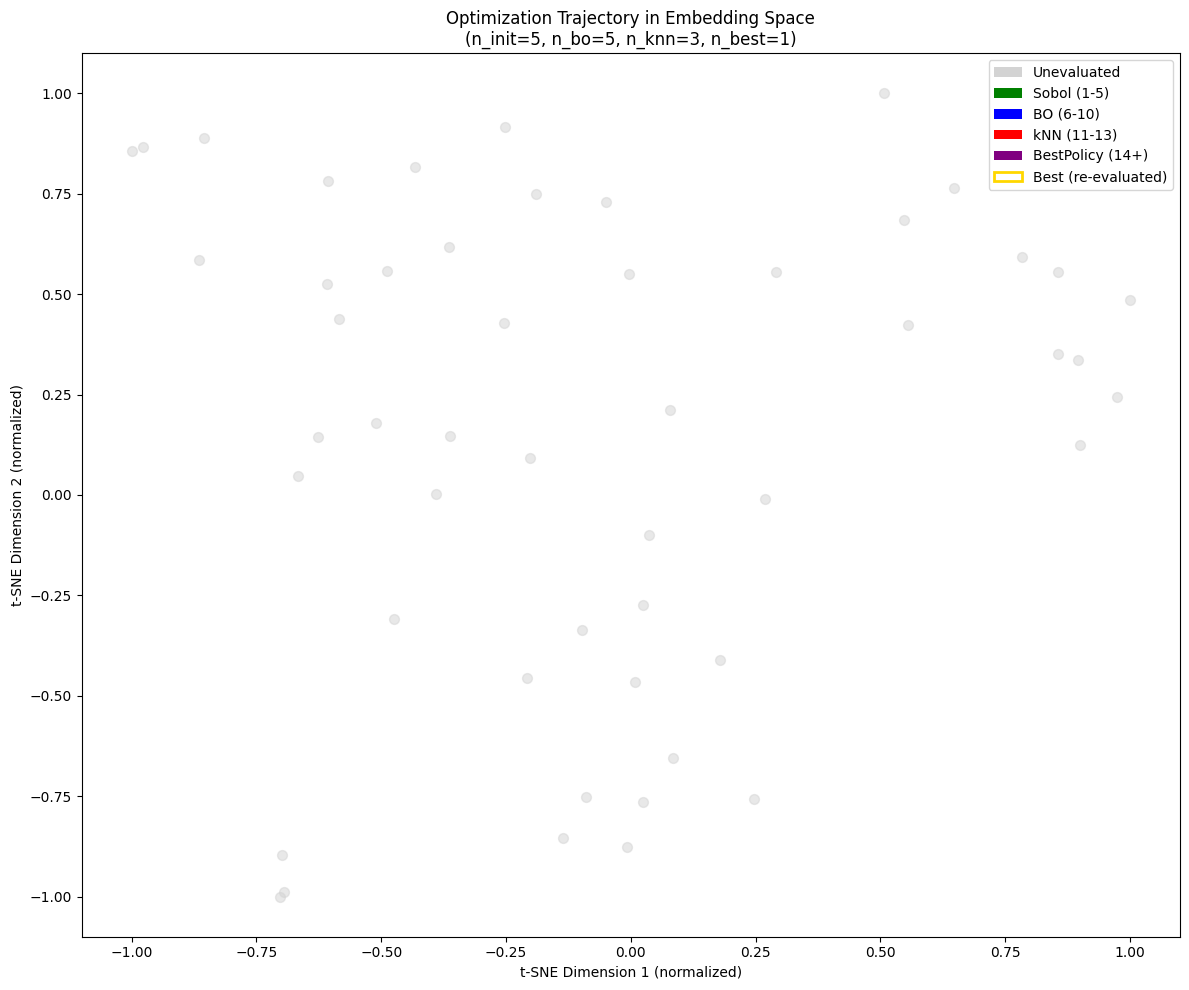


Total evaluated policies: 14
Remaining policies: 38


In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Circle

fig, ax = plt.subplots(figsize=(12, 10))

# Plot all policies (gray background)
ax.scatter(opt._coords[:, 0], opt._coords[:, 1], c='lightgray', alpha=0.5, s=50, label='Unevaluated')

# Track best trial for highlighting
best_policy, best_params, _, best_trial_idx, _ = opt.get_best()
best_coords = None

# Plot evaluated policies with order numbers and color by phase
for i, (trial_idx, policy) in enumerate(sorted(opt.trial_to_policy.items())):
    idx_arr = np.where(opt._policy_names == policy)[0]
    if len(idx_arr) > 0:
        coords = opt._coords[idx_arr[0]]
        # Color by phase: green=Sobol, blue=BO, red=kNN, purple=BestPolicy
        if i < opt.n_init:
            color = 'green'
        elif i < opt.n_init + opt.n_bo_trials:
            color = 'blue'
        elif i < opt.n_init + opt.n_bo_trials + opt.n_knn_neighbors:
            color = 'red'
        else:
            color = 'purple'
        ax.scatter(coords[0], coords[1], c=color, s=100, zorder=5, edgecolors='black', linewidths=0.5)
        ax.annotate(str(i+1), (coords[0], coords[1]), fontsize=8, ha='center', va='bottom',
                   xytext=(0, 5), textcoords='offset points')
        
        # Track best coords
        if policy == best_policy:
            best_coords = coords

# Draw circle around best policy to show it was re-evaluated
if best_coords is not None:
    circle = Circle((best_coords[0], best_coords[1]), 0.08, fill=False, 
                    color='gold', linewidth=3, linestyle='-', zorder=4)
    ax.add_patch(circle)

ax.set_xlabel('t-SNE Dimension 1 (normalized)')
ax.set_ylabel('t-SNE Dimension 2 (normalized)')
ax.set_title(f'Optimization Trajectory in Embedding Space\n(n_init={opt.n_init}, n_bo={opt.n_bo_trials}, n_knn={opt.n_knn_neighbors}, n_best={opt.n_best_trials})')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

# Add legend
knn_end = opt.n_init + opt.n_bo_trials + opt.n_knn_neighbors
legend_elements = [
    Patch(facecolor='lightgray', label='Unevaluated'),
    Patch(facecolor='green', label=f'Sobol (1-{opt.n_init})'),
    Patch(facecolor='blue', label=f'BO ({opt.n_init+1}-{opt.n_init + opt.n_bo_trials})'),
    Patch(facecolor='red', label=f'kNN ({opt.n_init + opt.n_bo_trials + 1}-{knn_end})'),
    Patch(facecolor='purple', label=f'BestPolicy ({knn_end + 1}+)'),
    Patch(facecolor='none', edgecolor='gold', linewidth=2, label='Best (re-evaluated)'),
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nTotal evaluated policies: {len(opt.trial_to_policy)}")
print(f"Remaining policies: {opt.remaining_policies()}")

In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from ax.core.observation import ObservationFeatures
from botorch.models import SingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
import torch

# Create grid for heatmap
grid_size = 30
x_grid = np.linspace(-1, 1, grid_size)
y_grid = np.linspace(-1, 1, grid_size)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

# Get sorted trials
sorted_trials = sorted(opt.trial_to_policy.items())
experiment = opt._optimizer.client._experiment
data = experiment.lookup_data()

# Collect trial data in order
trial_data = []
for trial_idx, policy in sorted_trials:
    trial = experiment.trials[trial_idx]
    params = trial.arm.parameters
    trial_df = data.df[(data.df["trial_index"] == trial_idx) & (data.df["metric_name"] == "performance")]
    if not trial_df.empty:
        value = trial_df["mean"].item()
        trial_data.append({
            'trial_idx': trial_idx,
            'policy': policy,
            'x': params['emb_x'],
            'y': params['emb_y'],
            'value': value
        })

# Setup figure
fig, ax = plt.subplots(figsize=(10, 8))

def get_phase_color(i):
    if i < opt.n_init:
        return 'green'
    elif i < opt.n_init + opt.n_bo_trials:
        return 'blue'
    elif i < opt.n_init + opt.n_bo_trials + opt.n_knn_neighbors:
        return 'red'
    return 'purple'

def animate(frame):
    ax.clear()
    
    # Need at least 2 points to fit GP
    n_points = frame + 1
    if n_points < 2:
        n_points = 2
    
    current_data = trial_data[:n_points]
    
    # Fit GP with current data
    X = torch.tensor([[d['x'], d['y']] for d in current_data], dtype=torch.float64)
    Y = torch.tensor([[d['value']] for d in current_data], dtype=torch.float64)
    
    # Normalize Y for better GP fitting
    Y_mean, Y_std = Y.mean(), Y.std()
    if Y_std > 0:
        Y_norm = (Y - Y_mean) / Y_std
    else:
        Y_norm = Y - Y_mean
    
    try:
        model = SingleTaskGP(X, Y_norm)
        model.eval()
        
        # Predict on grid
        with torch.no_grad():
            X_grid = torch.tensor(grid_points, dtype=torch.float64)
            posterior = model.posterior(X_grid)
            means = posterior.mean.numpy().flatten()
            # Denormalize
            means = means * Y_std.item() + Y_mean.item()
            means = means.reshape(grid_size, grid_size)
        
        # Plot heatmap
        vmin = min(d['value'] for d in trial_data)
        vmax = max(d['value'] for d in trial_data)
        im = ax.contourf(xx, yy, means, levels=20, cmap='RdYlGn', alpha=0.7, vmin=vmin, vmax=vmax)
    except Exception as e:
        pass  # Skip heatmap if GP fails
    
    # Plot all policies (gray background)
    ax.scatter(opt._coords[:, 0], opt._coords[:, 1], c='lightgray', alpha=0.3, s=30)
    
    # Plot evaluated points up to current frame
    for i, d in enumerate(current_data):
        color = get_phase_color(i)
        ax.scatter(d['x'], d['y'], c=color, s=120, zorder=5, edgecolors='black', linewidths=1)
        ax.annotate(str(i+1), (d['x'], d['y']), fontsize=9, ha='center', va='center',
                   fontweight='bold', color='white')
    
    # Highlight best so far
    best_idx = max(range(len(current_data)), key=lambda i: current_data[i]['value'])
    best = current_data[best_idx]
    circle = Circle((best['x'], best['y']), 0.08, fill=False, color='gold', linewidth=3, zorder=6)
    ax.add_patch(circle)
    
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel('emb_x')
    ax.set_ylabel('emb_y')
    ax.set_title(f'GP Heatmap Evolution - Trial {n_points}/{len(trial_data)}\nBest so far: {best["value"]:.0f}')
    
    return []

# Create animation
anim = FuncAnimation(fig, animate, frames=len(trial_data), interval=1000, blit=True)
plt.close()  # Prevent static display

# Display as HTML5 video
HTML(anim.to_jshtml())

C:\Users\dedong1\work\Overcooked_equilibrium\.venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning:

Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.

C:\Users\dedong1\work\Overcooked_equilibrium\.venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning:

Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.



In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from botorch.models import SingleTaskGP
import torch

# Get sorted trials and data (reuse from previous cell)
sorted_trials = sorted(opt.trial_to_policy.items())
experiment = opt._optimizer.client._experiment
data = experiment.lookup_data()

trial_data = []
for trial_idx, policy in sorted_trials:
    trial = experiment.trials[trial_idx]
    params = trial.arm.parameters
    trial_df = data.df[(data.df["trial_index"] == trial_idx) & (data.df["metric_name"] == "performance")]
    if not trial_df.empty:
        value = trial_df["mean"].item()
        trial_data.append({
            'trial_idx': trial_idx,
            'policy': policy,
            'x': params['emb_x'],
            'y': params['emb_y'],
            'value': value
        })

# Grid for 1D slices
x_line = np.linspace(-1, 1, 100)

def get_phase_color(i):
    if i < opt.n_init:
        return 'green'
    elif i < opt.n_init + opt.n_bo_trials:
        return 'blue'
    elif i < opt.n_init + opt.n_bo_trials + opt.n_knn_neighbors:
        return 'red'
    return 'purple'

# Setup figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def animate(frame):
    for ax in axes:
        ax.clear()
    
    n_points = frame + 1
    if n_points < 2:
        n_points = 2
    
    current_data = trial_data[:n_points]
    
    # Fit GP
    X = torch.tensor([[d['x'], d['y']] for d in current_data], dtype=torch.float64)
    Y = torch.tensor([[d['value']] for d in current_data], dtype=torch.float64)
    
    Y_mean, Y_std = Y.mean(), Y.std()
    if Y_std > 0:
        Y_norm = (Y - Y_mean) / Y_std
    else:
        Y_norm = Y - Y_mean
    
    vmin = min(d['value'] for d in trial_data)
    vmax = max(d['value'] for d in trial_data)
    
    try:
        model = SingleTaskGP(X, Y_norm)
        model.eval()
        
        # Get current best point for slice reference
        best_idx = max(range(len(current_data)), key=lambda i: current_data[i]['value'])
        best = current_data[best_idx]
        
        with torch.no_grad():
            # Slice along emb_x (fix y at best y)
            X_slice_x = torch.tensor([[x, best['y']] for x in x_line], dtype=torch.float64)
            post_x = model.posterior(X_slice_x)
            mean_x = post_x.mean.numpy().flatten() * Y_std.item() + Y_mean.item()
            std_x = np.sqrt(post_x.variance.numpy().flatten()) * Y_std.item()
            
            # Slice along emb_y (fix x at best x)
            X_slice_y = torch.tensor([[best['x'], y] for y in x_line], dtype=torch.float64)
            post_y = model.posterior(X_slice_y)
            mean_y = post_y.mean.numpy().flatten() * Y_std.item() + Y_mean.item()
            std_y = np.sqrt(post_y.variance.numpy().flatten()) * Y_std.item()
        
        # Plot emb_x slice
        axes[0].fill_between(x_line, mean_x - 2*std_x, mean_x + 2*std_x, alpha=0.3, color='blue')
        axes[0].plot(x_line, mean_x, 'b-', linewidth=2, label='GP mean')
        for i, d in enumerate(current_data):
            axes[0].scatter(d['x'], d['value'], c=get_phase_color(i), s=80, zorder=5, edgecolors='black')
        axes[0].axvline(best['x'], color='gold', linestyle='--', linewidth=2, label=f'Best x={best["x"]:.2f}')
        axes[0].set_xlabel('emb_x')
        axes[0].set_ylabel('Performance')
        axes[0].set_title(f'GP Slice: emb_x (y fixed at {best["y"]:.2f})')
        axes[0].set_xlim(-1.1, 1.1)
        axes[0].set_ylim(vmin - 50, vmax + 50)
        axes[0].legend(loc='lower right', fontsize=8)
        
        # Plot emb_y slice
        axes[1].fill_between(x_line, mean_y - 2*std_y, mean_y + 2*std_y, alpha=0.3, color='red')
        axes[1].plot(x_line, mean_y, 'r-', linewidth=2, label='GP mean')
        for i, d in enumerate(current_data):
            axes[1].scatter(d['y'], d['value'], c=get_phase_color(i), s=80, zorder=5, edgecolors='black')
        axes[1].axvline(best['y'], color='gold', linestyle='--', linewidth=2, label=f'Best y={best["y"]:.2f}')
        axes[1].set_xlabel('emb_y')
        axes[1].set_ylabel('Performance')
        axes[1].set_title(f'GP Slice: emb_y (x fixed at {best["x"]:.2f})')
        axes[1].set_xlim(-1.1, 1.1)
        axes[1].set_ylim(vmin - 50, vmax + 50)
        axes[1].legend(loc='lower right', fontsize=8)
        
        # 2D heatmap
        grid_size = 25
        xx, yy = np.meshgrid(np.linspace(-1, 1, grid_size), np.linspace(-1, 1, grid_size))
        X_grid = torch.tensor(np.column_stack([xx.ravel(), yy.ravel()]), dtype=torch.float64)
        with torch.no_grad():
            means = model.posterior(X_grid).mean.numpy().flatten()
            means = means * Y_std.item() + Y_mean.item()
            means = means.reshape(grid_size, grid_size)
        
        im = axes[2].contourf(xx, yy, means, levels=15, cmap='RdYlGn', alpha=0.7, vmin=vmin, vmax=vmax)
        axes[2].scatter(opt._coords[:, 0], opt._coords[:, 1], c='lightgray', alpha=0.3, s=20)
        for i, d in enumerate(current_data):
            axes[2].scatter(d['x'], d['y'], c=get_phase_color(i), s=80, zorder=5, edgecolors='black')
            axes[2].annotate(str(i+1), (d['x'], d['y']), fontsize=8, ha='center', va='center', color='white', fontweight='bold')
        axes[2].scatter(best['x'], best['y'], s=200, facecolors='none', edgecolors='gold', linewidths=3, zorder=6)
        axes[2].set_xlabel('emb_x')
        axes[2].set_ylabel('emb_y')
        axes[2].set_title('2D GP Heatmap')
        axes[2].set_xlim(-1.1, 1.1)
        axes[2].set_ylim(-1.1, 1.1)
        
    except Exception as e:
        axes[0].text(0, 0, f'GP fit failed: {e}', ha='center')
    
    fig.suptitle(f'GP Evolution - Trial {n_points}/{len(trial_data)}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return []

anim = FuncAnimation(fig, animate, frames=len(trial_data), interval=1200, blit=True)
plt.close()

HTML(anim.to_jshtml())

C:\Users\dedong1\work\Overcooked_equilibrium\.venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning:

Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.



<Figure size 640x480 with 0 Axes>

## Generate Final Visualizations

Generate the complete PDF visualizations with GP heatmap and sample order annotations.

In [9]:
# # Generate final visualizations with GP heatmap and sample order
# # This saves PDFs to submissions/{prolificId}/

# opt.generate_final_visualizations(str(prolificId))

# print(f"Visualizations saved to submissions/{prolificId}/")
# print("Generated files:")
# print("  - embedding_trajectory_with_gp.pdf (GP heatmap + sample order)")
# print("  - slice_emb_x.pdf (with sample annotations)")
# print("  - slice_emb_y.pdf (with sample annotations)")
# print("  - contour_with_samples.pdf (contour plot with sample points)")